In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split


In [3]:
df = pd.read_csv('train.csv')
print(df.shape)
df.head()

(45528, 19)


,customer_id,name,age,gender,owns_car,owns_house,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,default_in_last_6months,credit_card_default
0,CST_115179,ita Bose,46,F,N,Y,0.0,107934.04,612.0,Unknown,1.0,1.0,33070.28,18690.93,73,544.0,2,1,1
1,CST_121920,Alper Jonathan,29,M,N,Y,0.0,109862.62,2771.0,Laborers,2.0,0.0,15329.53,37745.19,52,857.0,0,0,0
2,CST_109330,Umesh Desai,37,M,N,Y,0.0,230153.17,204.0,Laborers,2.0,0.0,48416.60,41598.36,43,650.0,0,0,0
3,CST_128288,Rie,39,F,N,Y,0.0,122325.82,11941.0,Core staff,2.0,0.0,22574.36,32627.76,20,754.0,0,0,0
4,CST_151355,McCool,46,M,Y,Y,0.0,387286.00,1459.0,Core staff,1.0,0.0,38282.95,52950.64,75,927.0,0,0,0


In [4]:
df["credit_card_default"].value_counts(normalize=True)

,proportion
credit_card_default,
0,0.918797
1,0.081203


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45528 entries, 0 to 45527
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              45528 non-null  object 
 1   name                     45528 non-null  object 
 2   age                      45528 non-null  int64  
 3   gender                   45528 non-null  object 
 4   owns_car                 44981 non-null  object 
 5   owns_house               45528 non-null  object 
 6   no_of_children           44754 non-null  float64
 7   net_yearly_income        45528 non-null  float64
 8   no_of_days_employed      45065 non-null  float64
 9   occupation_type          45528 non-null  object 
 10  total_family_members     45445 non-null  float64
 11  migrant_worker           45441 non-null  float64
 12  yearly_debt_payments     45433 non-null  float64
 13  credit_limit             45528 non-null  float64
 14  credit_limit_used(%)  

In [6]:
cat_feats = [col for col in df.columns if df[col].dtypes == "object"]
num_feats =  [col for col in df.columns if df[col].dtypes != "object"]

print("no of cat feats: ", len(cat_feats))
print("no of num feats: ", len(num_feats))

no of cat feats:  6
no of num feats:  13


In [8]:
cat_feats


['customer_id', 'name', 'gender', 'owns_car', 'owns_house', 'occupation_type']

In [9]:
num_feats

['age',
 'no_of_children',
 'net_yearly_income',
 'no_of_days_employed',
 'total_family_members',
 'migrant_worker',
 'yearly_debt_payments',
 'credit_limit',
 'credit_limit_used(%)',
 'credit_score',
 'prev_defaults',
 'default_in_last_6months',
 'credit_card_default']

In [10]:
df = df.drop(['customer_id', 'name'], axis=1)
df

,age,gender,owns_car,owns_house,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,default_in_last_6months,credit_card_default
0,46,F,N,Y,0.0,107934.04,612.0,Unknown,1.0,1.0,33070.28,18690.93,73,544.0,2,1,1
1,29,M,N,Y,0.0,109862.62,2771.0,Laborers,2.0,0.0,15329.53,37745.19,52,857.0,0,0,0
2,37,M,N,Y,0.0,230153.17,204.0,Laborers,2.0,0.0,48416.60,41598.36,43,650.0,0,0,0
3,39,F,N,Y,0.0,122325.82,11941.0,Core staff,2.0,0.0,22574.36,32627.76,20,754.0,0,0,0
4,46,M,Y,Y,0.0,387286.00,1459.0,Core staff,1.0,0.0,38282.95,52950.64,75,927.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45523,55,F,N,N,2.0,96207.57,117.0,Unknown,4.0,0.0,11229.54,29663.83,82,907.0,0,0,0
45524,31,F,N,Y,0.0,383476.74,966.0,Accountants,2.0,1.0,43369.91,139947.16,32,679.0,0,0,0
45525,27,F,N,Y,0.0,260052.18,1420.0,Core staff,2.0,0.0,22707.51,83961.83,46,727.0,0,0,0
45526,32,M,Y,N,0.0,157363.04,2457.0,Laborers,2.0,0.0,20150.10,25538.72,92,805.0,0,0,0


In [11]:
for col in df.columns:
    temp = df[col].isnull().sum()
    print(f'Column {col} contains {temp} null values.')

Column age contains 0 null values.
Column gender contains 0 null values.
Column owns_car contains 547 null values.
Column owns_house contains 0 null values.
Column no_of_children contains 774 null values.
Column net_yearly_income contains 0 null values.
Column no_of_days_employed contains 463 null values.
Column occupation_type contains 0 null values.
Column total_family_members contains 83 null values.
Column migrant_worker contains 87 null values.
Column yearly_debt_payments contains 95 null values.
Column credit_limit contains 0 null values.
Column credit_limit_used(%) contains 0 null values.
Column credit_score contains 8 null values.
Column prev_defaults contains 0 null values.
Column default_in_last_6months contains 0 null values.
Column credit_card_default contains 0 null values.


In [12]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Column: gender
gender
F      29957
M      15570
XNA        1
Name: count, dtype: int64

Column: owns_car
owns_car
N    29743
Y    15238
Name: count, dtype: int64

Column: owns_house
owns_house
Y    31642
N    13886
Name: count, dtype: int64

Column: occupation_type
occupation_type
Unknown                  14299
Laborers                  8134
Sales staff               4725
Core staff                4062
Managers                  3168
Drivers                   2747
High skill tech staff     1682
Accountants               1474
Medicine staff            1275
Security staff            1025
Cooking staff              902
Cleaning staff             665
Private service staff      387
Low-skill Laborers         336
Waiters/barmen staff       203
Secretaries                199
Realty agents              101
HR staff                    78
IT staff                    66
Name: count, dtype: int64


In [13]:
df.dropna(subset=num_feats, inplace=True)
print(df.shape)

df[num_feats].isnull().sum()

(44030, 17)


,0
age,0
no_of_children,0
net_yearly_income,0
no_of_days_employed,0
total_family_members,0
migrant_worker,0
yearly_debt_payments,0
credit_limit,0
credit_limit_used(%),0
credit_score,0


In [14]:
df = df[df['occupation_type'] != 'Unknown']
print(df.shape)

(30193, 17)


In [15]:
df = df[df['gender'] != 'XNA']
print(df.shape)

(30192, 17)


In [16]:
laborers_to_drop = df[df['occupation_type'] == 'Laborers'].sample(n=192, random_state=42).index
df = df.drop(laborers_to_drop)
print(df.shape)
df

(30000, 17)


,age,gender,owns_car,owns_house,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,default_in_last_6months,credit_card_default
1,29,M,N,Y,0.0,109862.62,2771.0,Laborers,2.0,0.0,15329.53,37745.19,52,857.0,0,0,0
2,37,M,N,Y,0.0,230153.17,204.0,Laborers,2.0,0.0,48416.60,41598.36,43,650.0,0,0,0
3,39,F,N,Y,0.0,122325.82,11941.0,Core staff,2.0,0.0,22574.36,32627.76,20,754.0,0,0,0
4,46,M,Y,Y,0.0,387286.00,1459.0,Core staff,1.0,0.0,38282.95,52950.64,75,927.0,0,0,0
5,46,F,Y,N,0.0,252765.91,2898.0,Accountants,2.0,1.0,37046.86,40245.64,19,937.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45518,54,F,N,Y,2.0,252941.68,2266.0,Laborers,3.0,0.0,37513.38,45775.43,71,677.0,0,0,1
45519,41,M,Y,Y,2.0,293494.24,794.0,Core staff,4.0,0.0,40402.37,83883.37,97,665.0,0,0,0
45520,47,M,Y,Y,0.0,291628.76,1677.0,Drivers,1.0,0.0,15627.73,42980.82,85,915.0,0,0,0
45524,31,F,N,Y,0.0,383476.74,966.0,Accountants,2.0,1.0,43369.91,139947.16,32,679.0,0,0,0


In [17]:
for col in df.columns:
    temp = df[col].isnull().sum()
    print(f'Column {col} contains {temp} null values.')

Column age contains 0 null values.
Column gender contains 0 null values.
Column owns_car contains 358 null values.
Column owns_house contains 0 null values.
Column no_of_children contains 0 null values.
Column net_yearly_income contains 0 null values.
Column no_of_days_employed contains 0 null values.
Column occupation_type contains 0 null values.
Column total_family_members contains 0 null values.
Column migrant_worker contains 0 null values.
Column yearly_debt_payments contains 0 null values.
Column credit_limit contains 0 null values.
Column credit_limit_used(%) contains 0 null values.
Column credit_score contains 0 null values.
Column prev_defaults contains 0 null values.
Column default_in_last_6months contains 0 null values.
Column credit_card_default contains 0 null values.


In [18]:
from sklearn.preprocessing import OneHotEncoder
nominal_cols = ['gender', 'owns_car',  'owns_house','migrant_worker','occupation_type']



encoder = OneHotEncoder(drop='first', sparse_output=False)
one_hot_encoded = encoder.fit_transform(df[nominal_cols])
one_hot_df = pd.DataFrame(one_hot_encoded,columns=encoder.get_feature_names_out(nominal_cols))

one_hot_df.reset_index(drop=True, inplace=True)
df.reset_index(drop=True, inplace=True)

df_encoded = pd.concat([df.drop(nominal_cols, axis=1), one_hot_df], axis=1)
df_encoded.head()

,age,no_of_children,net_yearly_income,no_of_days_employed,total_family_members,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,...,occupation_type_Laborers,occupation_type_Low-skill Laborers,occupation_type_Managers,occupation_type_Medicine staff,occupation_type_Private service staff,occupation_type_Realty agents,occupation_type_Sales staff,occupation_type_Secretaries,occupation_type_Security staff,occupation_type_Waiters/barmen staff
0,29,0.0,109862.62,2771.0,2.0,15329.53,37745.19,52,857.0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,37,0.0,230153.17,204.0,2.0,48416.60,41598.36,43,650.0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,39,0.0,122325.82,11941.0,2.0,22574.36,32627.76,20,754.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,46,0.0,387286.00,1459.0,1.0,38282.95,52950.64,75,927.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,46,0.0,252765.91,2898.0,2.0,37046.86,40245.64,19,937.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
for col in df_encoded.columns:
    temp = df_encoded[col].isnull().sum()
    print(f'Column {col} contains {temp} null values.')

Column age contains 0 null values.
Column no_of_children contains 0 null values.
Column net_yearly_income contains 0 null values.
Column no_of_days_employed contains 0 null values.
Column total_family_members contains 0 null values.
Column yearly_debt_payments contains 0 null values.
Column credit_limit contains 0 null values.
Column credit_limit_used(%) contains 0 null values.
Column credit_score contains 0 null values.
Column prev_defaults contains 0 null values.
Column default_in_last_6months contains 0 null values.
Column credit_card_default contains 0 null values.
Column gender_M contains 0 null values.
Column owns_car_Y contains 0 null values.
Column owns_car_nan contains 0 null values.
Column owns_house_Y contains 0 null values.
Column migrant_worker_1.0 contains 0 null values.
Column occupation_type_Cleaning staff contains 0 null values.
Column occupation_type_Cooking staff contains 0 null values.
Column occupation_type_Core staff contains 0 null values.
Column occupation_type_

In [20]:
from sklearn.preprocessing import MinMaxScaler
numerical_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns
scaler = MinMaxScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])


print(df_encoded.head())

       age  no_of_children  net_yearly_income  no_of_days_employed  \
0  0.18750             0.0           0.000573             0.157904   
1  0.43750             0.0           0.001428             0.011519   
2  0.50000             0.0           0.000662             0.680828   
3  0.71875             0.0           0.002545             0.083086   
4  0.71875             0.0           0.001589             0.165146   

   total_family_members  yearly_debt_payments  credit_limit  \
0              0.111111              0.036951      0.001083   
1              0.111111              0.138825      0.001207   
2              0.111111              0.059258      0.000919   
3              0.000000              0.107624      0.001572   
4              0.111111              0.103818      0.001163   

   credit_limit_used(%)  credit_score  prev_defaults  ...  \
0              0.525253      0.795100            0.0  ...   
1              0.434343      0.334076            0.0  ...   
2              0.

In [21]:
df_encoded

,age,no_of_children,net_yearly_income,no_of_days_employed,total_family_members,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,...,occupation_type_Laborers,occupation_type_Low-skill Laborers,occupation_type_Managers,occupation_type_Medicine staff,occupation_type_Private service staff,occupation_type_Realty agents,occupation_type_Sales staff,occupation_type_Secretaries,occupation_type_Security staff,occupation_type_Waiters/barmen staff
0,0.18750,0.000000,0.000573,0.157904,0.111111,0.036951,0.001083,0.525253,0.795100,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.43750,0.000000,0.001428,0.011519,0.111111,0.138825,0.001207,0.434343,0.334076,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.50000,0.000000,0.000662,0.680828,0.111111,0.059258,0.000919,0.202020,0.565702,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.71875,0.000000,0.002545,0.083086,0.000000,0.107624,0.001572,0.757576,0.951002,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.71875,0.000000,0.001589,0.165146,0.111111,0.103818,0.001163,0.191919,0.973274,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,0.96875,0.222222,0.001590,0.129106,0.222222,0.105254,0.001341,0.717172,0.394209,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29996,0.56250,0.222222,0.001878,0.045164,0.333333,0.114150,0.002565,0.979798,0.367483,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29997,0.75000,0.000000,0.001865,0.095518,0.000000,0.037869,0.001251,0.858586,0.924276,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29998,0.25000,0.000000,0.002517,0.054973,0.111111,0.123286,0.004367,0.323232,0.398664,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
for col in df_encoded.columns:
    temp = df_encoded[col].isnull().sum()
    print(f'Column {col} contains {temp} null values.')

Column age contains 0 null values.
Column no_of_children contains 0 null values.
Column net_yearly_income contains 0 null values.
Column no_of_days_employed contains 0 null values.
Column total_family_members contains 0 null values.
Column yearly_debt_payments contains 0 null values.
Column credit_limit contains 0 null values.
Column credit_limit_used(%) contains 0 null values.
Column credit_score contains 0 null values.
Column prev_defaults contains 0 null values.
Column default_in_last_6months contains 0 null values.
Column credit_card_default contains 0 null values.
Column gender_M contains 0 null values.
Column owns_car_Y contains 0 null values.
Column owns_car_nan contains 0 null values.
Column owns_house_Y contains 0 null values.
Column migrant_worker_1.0 contains 0 null values.
Column occupation_type_Cleaning staff contains 0 null values.
Column occupation_type_Cooking staff contains 0 null values.
Column occupation_type_Core staff contains 0 null values.
Column occupation_type_

In [23]:
X = df_encoded.drop(['credit_card_default'], axis=1)
y = df_encoded['credit_card_default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

print("X=",X_train.shape, X_test.shape)
print("y=",y_train.shape, y_test.shape)

X= (21000, 33) (9000, 33)
y= (21000,) (9000,)


In [24]:
X_train.head()

,age,no_of_children,net_yearly_income,no_of_days_employed,total_family_members,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,...,occupation_type_Laborers,occupation_type_Low-skill Laborers,occupation_type_Managers,occupation_type_Medicine staff,occupation_type_Private service staff,occupation_type_Realty agents,occupation_type_Sales staff,occupation_type_Secretaries,occupation_type_Security staff,occupation_type_Waiters/barmen staff
11021,0.03125,0.000000,0.000898,0.094662,0.000000,0.037105,0.000946,0.222222,0.610245,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1556,0.50000,0.000000,0.000933,0.065693,0.111111,0.112867,0.000882,0.444444,0.982183,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2556,1.00000,0.000000,0.000608,0.080748,0.111111,0.031940,0.000731,0.969697,0.031180,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25143,0.40625,0.111111,0.000609,0.027372,0.222222,0.051630,0.000444,0.676768,0.585746,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9642,0.62500,0.000000,0.001114,0.056626,0.111111,0.094499,0.001945,0.151515,0.979955,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [25]:
y_train.head()

,credit_card_default
11021,0.0
1556,0.0
2556,1.0
25143,0.0
9642,0.0


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.978
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      8201
         1.0       0.99      0.76      0.86       799

    accuracy                           0.98      9000
   macro avg       0.98      0.88      0.92      9000
weighted avg       0.98      0.98      0.98      9000



In [27]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9778888888888889
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      8201
         1.0       0.99      0.76      0.86       799

    accuracy                           0.98      9000
   macro avg       0.98      0.88      0.92      9000
weighted avg       0.98      0.98      0.98      9000



Recall = True Positives / (True Positives + False Negatives)

Precision = True Positives / (True Positives + False Positives)


f1-score = 2 * (Precision * Recall) / (Precision + Recall)

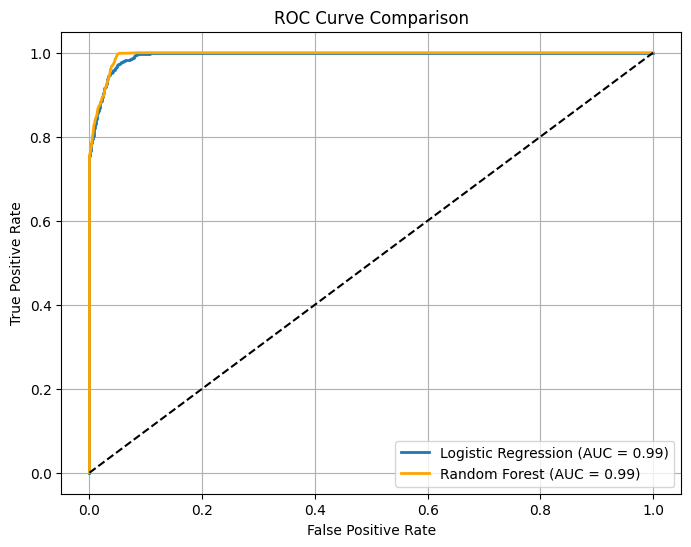

In [28]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get prediction probabilities
y_pred_log_proba = log_model.predict_proba(X_test)[:,1]
y_pred_rf_proba  = rf_model.predict_proba(X_test)[:,1]

# Compute ROC values
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_log_proba)
fpr_rf, tpr_rf, _   = roc_curve(y_test, y_pred_rf_proba)

# Compute AUC
auc_log = roc_auc_score(y_test, y_pred_log_proba)
auc_rf  = roc_auc_score(y_test, y_pred_rf_proba)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.2f})", lw=2)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})", lw=2, color="orange")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid()
plt.savefig("roc_auc_comparison.png", dpi=300)
plt.show()


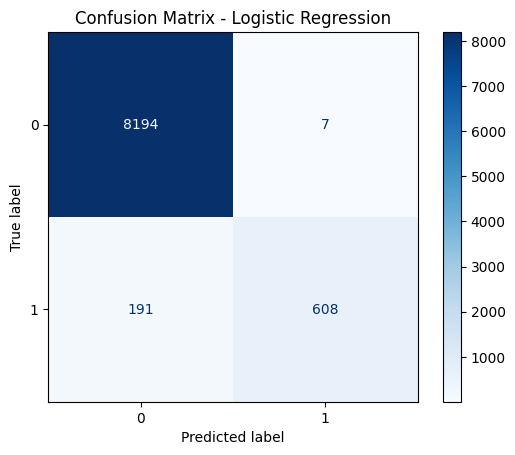

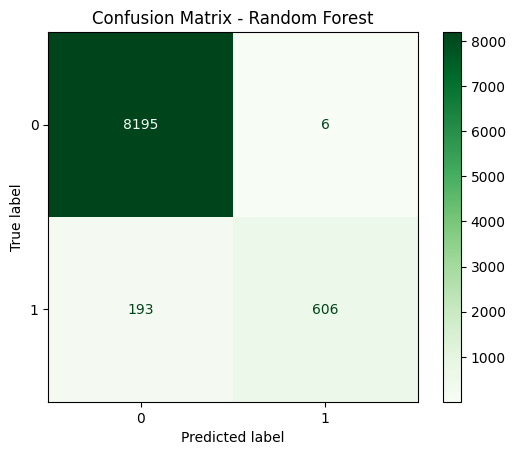

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.savefig("conf_matrix_log.png", dpi=300)
plt.show()

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot(cmap="Greens")
plt.title("Confusion Matrix - Random Forest")
plt.savefig("conf_matrix_rf.png", dpi=300)
plt.show()


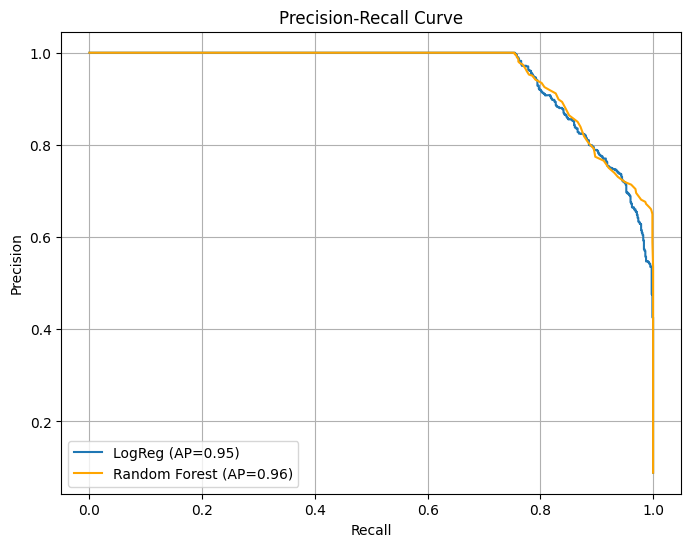

In [30]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Logistic Regression
precision_log, recall_log, _ = precision_recall_curve(y_test, y_pred_log_proba)
ap_log = average_precision_score(y_test, y_pred_log_proba)

# Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_rf_proba)
ap_rf = average_precision_score(y_test, y_pred_rf_proba)

plt.figure(figsize=(8,6))
plt.plot(recall_log, precision_log, label=f"LogReg (AP={ap_log:.2f})")
plt.plot(recall_rf, precision_rf, label=f"Random Forest (AP={ap_rf:.2f})", color="orange")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.grid()
plt.savefig("precision_recall.png", dpi=300)
plt.show()


/tmp/ipython-input-476114833.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_feats.values, y=top_feats.index, palette="viridis")


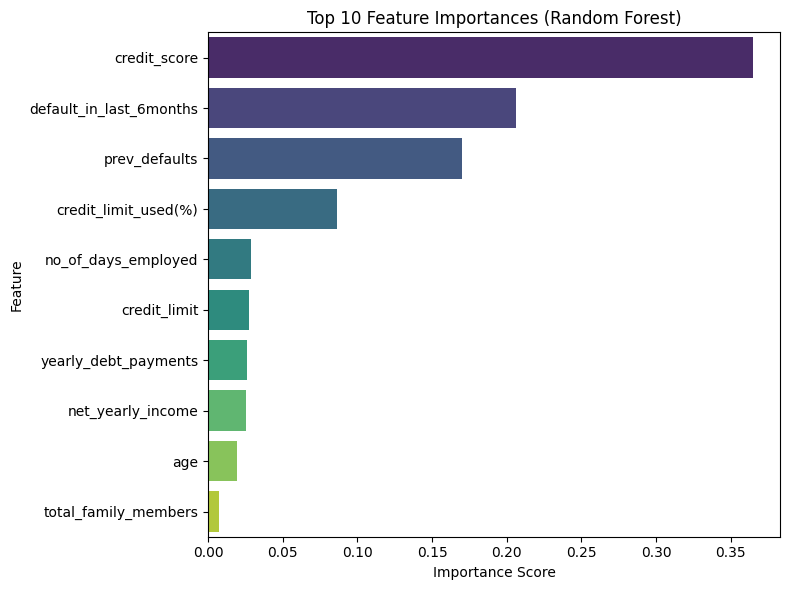

In [33]:

import seaborn as sns

importances = rf_model.feature_importances_
feat_importance = pd.Series(importances, index=X_train.columns)
top_feats = feat_importance.nlargest(10)

plt.figure(figsize=(8,6))
sns.barplot(x=top_feats.values, y=top_feats.index, palette="viridis")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()


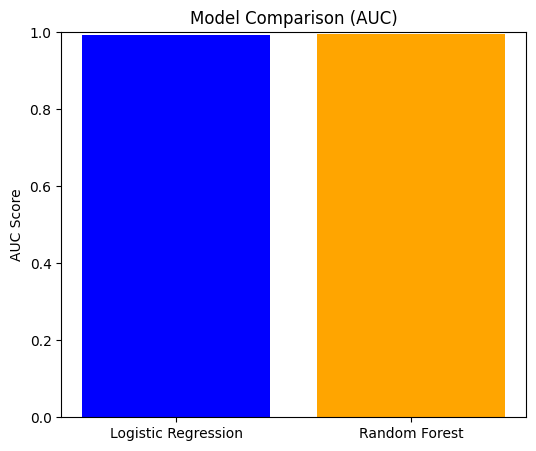

In [32]:
import numpy as np

models = ["Logistic Regression", "Random Forest"]
auc_scores = [auc_log, auc_rf]

plt.figure(figsize=(6,5))
plt.bar(models, auc_scores, color=["blue","orange"])
plt.title("Model Comparison (AUC)")
plt.ylabel("AUC Score")
plt.ylim(0,1)
plt.savefig("model_comparison.png", dpi=300)
plt.show()


In [35]:


# Model metrics
metrics = {
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "AUC": [auc_log, auc_rf],
    "Average Precision": [ap_log, ap_rf]
}

metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv("model_metrics.csv", index=False)

# Predictions with true labels
preds = pd.DataFrame({
    "Actual": y_test,
    "LogReg_Pred": y_pred_log,
    "RF_Pred": y_pred_rf
})
preds.to_csv("predictions.csv", index=False)

# Feature importances
feat_importance.to_csv("feature_importances.csv", index=True)

df.to_csv("cleaned_data.csv", index=False)

